# Polymarket Financial Market Calibration

This notebook studies whether lower-probability outcomes in resolved Polymarket financial markets are well calibrated one day before resolution.

**Main design choice:** one observation per binary market — the lower-priced outcome at the 24-hour horizon.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/05_snapshot_table.csv")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Load the existing snapshot dataset

The source table was generated from public Polymarket Gamma and CLOB data. The original pipeline already applies market-resolution, snapshot-staleness, and binary-pair consistency filters.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Rows: {len(df):,}")
print(f"Markets: {df['market_id'].nunique():,}")
print(f"Underlyings: {df['underlying'].nunique()}")
print("Horizons (minutes):", sorted(df['snapshot_horizon_min'].unique()))
df[['market_id','underlying','market_family','snapshot_horizon_min','price','realized']].head()

Rows: 35,594
Markets: 6,454
Underlyings: 11
Horizons (minutes): [np.int64(15), np.int64(60), np.int64(240), np.int64(1440), np.int64(4320), np.int64(10080), np.int64(20160)]


,market_id,underlying,market_family,snapshot_horizon_min,price,realized
0,2124740,SPY,daily_up_down,240,0.9630,1
1,2124740,SPY,daily_up_down,1440,0.6500,1
2,2124740,SPY,daily_up_down,240,0.0370,0
3,2124740,SPY,daily_up_down,1440,0.3500,0
4,2268191,SPY,daily_up_down,240,0.2350,0


## 2. Build the 24-hour one-market-one-observation sample

For each market we select the lower-priced token at 1,440 minutes before resolution. Because a binary market has complementary outcomes, this is the market's lower-probability side. A single anomalous pair whose lower side is above 50% is excluded.

In [3]:
one_day = df.loc[df['snapshot_horizon_min'].eq(1440)].copy()

pair_sizes = one_day.groupby('market_id').size()
pair_sums = one_day.groupby('market_id')['price'].sum()

print(f"24h rows: {len(one_day):,}")
print(f"24h markets: {one_day['market_id'].nunique():,}")
print("Rows per market:")
print(pair_sizes.value_counts().sort_index())
print(f"Maximum |p1+p2-1|: {(pair_sums - 1).abs().max():.4f}")

24h rows: 11,774
24h markets: 5,887
Rows per market:
2    5887
Name: count, dtype: int64
Maximum |p1+p2-1|: 0.0500


In [4]:
idx = one_day.groupby('market_id')['price'].idxmin()
longshots = one_day.loc[idx].copy()
longshots = longshots.loc[longshots['price'].le(0.50)].copy()
longshots['resolution_date'] = pd.to_datetime(longshots['resolution_iso'], errors='coerce', utc=True)
longshots['bias'] = longshots['realized'] - longshots['price']

print(f"Final one-market sample: {len(longshots):,}")
print(f"Date range: {longshots['resolution_date'].min().date()} to {longshots['resolution_date'].max().date()}")
print("Underlyings:", ', '.join(sorted(longshots['underlying'].dropna().unique())))

Final one-market sample: 5,886
Date range: 2025-01-01 to 2026-05-25
Underlyings: AAPL, AMZN, GOOGL, NFLX, NVDA, SPX, SPY, TSLA, WTI, XAGUSD_SI, XAUUSD_GC


## 3. Aggregate calibration

Calibration error is defined as

\[
	ext{bias} = y - p,
\]

where `p` is the Polymarket implied probability and `y` is the realized binary outcome. Negative values mean the outcome occurred less often than its price implied.

In [5]:
overall = pd.Series({
    'n_markets': len(longshots),
    'avg_implied_probability': longshots['price'].mean(),
    'observed_frequency': longshots['realized'].mean(),
    'calibration_error': longshots['bias'].mean(),
    'brier_score': np.mean((longshots['realized'] - longshots['price'])**2),
})
overall

n_markets                 5,886.0000
avg_implied_probability       0.2245
observed_frequency            0.2015
calibration_error            -0.0230
brier_score                   0.1262
dtype: float64

The lower-priced side is modestly overestimated on average in this sample: its observed frequency is below its average implied probability. The next sections show whether this pattern is concentrated in specific probability ranges or underlyings.

## 4. Calibration by implied-probability bucket

In [6]:
bins = [0, 0.01, 0.02, 0.05, 0.10, 0.20, 0.35, 0.50]
labels = ['≤1%', '1–2%', '2–5%', '5–10%', '10–20%', '20–35%', '35–50%']
longshots['probability_bucket'] = pd.cut(
    longshots['price'], bins=bins, labels=labels, include_lowest=True
)

rng = np.random.default_rng(12345)

def bootstrap_mean_ci(values, iterations=3000):
    x = np.asarray(pd.Series(values).dropna(), dtype=float)
    if len(x) < 2:
        return np.nan, np.nan
    boot = np.empty(iterations)
    for i in range(iterations):
        boot[i] = rng.choice(x, size=len(x), replace=True).mean()
    return tuple(np.quantile(boot, [0.025, 0.975]))

rows = []
for bucket, sub in longshots.groupby('probability_bucket', observed=True):
    lo, hi = bootstrap_mean_ci(sub['bias'])
    rows.append({
        'probability_bucket': str(bucket),
        'n_markets': len(sub),
        'avg_price': sub['price'].mean(),
        'realized_rate': sub['realized'].mean(),
        'calibration_error': sub['bias'].mean(),
        'bootstrap_lo95': lo,
        'bootstrap_hi95': hi,
        'brier_score': np.mean((sub['realized'] - sub['price'])**2),
    })

bucket_summary = pd.DataFrame(rows)
bucket_summary.to_csv(RESULTS_DIR / 'summary_by_probability_bucket_1d.csv', index=False)
bucket_summary

,probability_bucket,n_markets,avg_price,realized_rate,calibration_error,bootstrap_lo95,bootstrap_hi95,brier_score
0,≤1%,824,0.0046,0.0000,-0.0046,-0.0048,-0.0044,0.0000
1,1–2%,372,0.0148,0.0108,-0.0041,-0.0123,0.0067,0.0106
2,2–5%,606,0.0337,0.0149,-0.0188,-0.0274,-0.0088,0.0150
3,5–10%,679,0.0722,0.0383,-0.0339,-0.0473,-0.0185,0.0379
4,10–20%,567,0.1470,0.1217,-0.0253,-0.0520,0.0018,0.1060
5,20–35%,780,0.2845,0.2333,-0.0512,-0.0793,-0.0223,0.1814
6,35–50%,2058,0.4555,0.4354,-0.0201,-0.0420,0.0013,0.2442


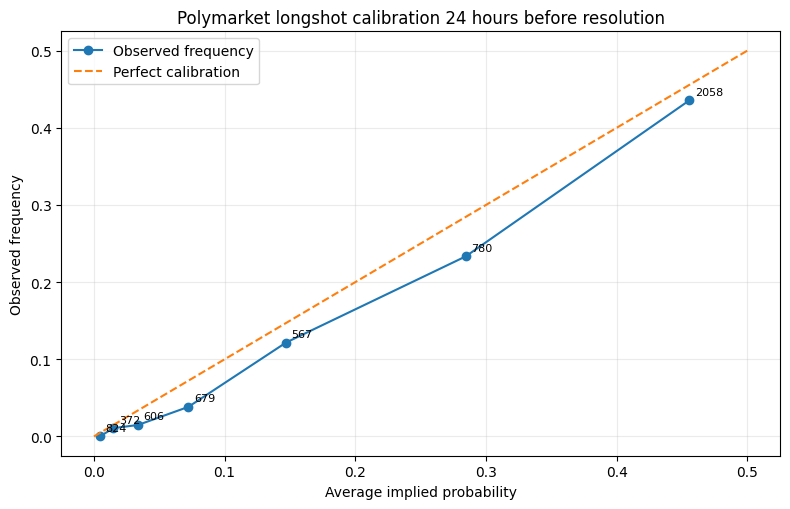

In [7]:
plt.figure(figsize=(8, 5.2))
plt.plot(bucket_summary['avg_price'], bucket_summary['realized_rate'], marker='o', label='Observed frequency')
plt.plot([0, 0.5], [0, 0.5], linestyle='--', label='Perfect calibration')
for _, r in bucket_summary.iterrows():
    plt.annotate(str(int(r['n_markets'])), (r['avg_price'], r['realized_rate']), xytext=(4, 4), textcoords='offset points', fontsize=8)
plt.xlabel('Average implied probability')
plt.ylabel('Observed frequency')
plt.title('Polymarket longshot calibration 24 hours before resolution')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'calibration_curve_1d.png', dpi=160)
plt.show()

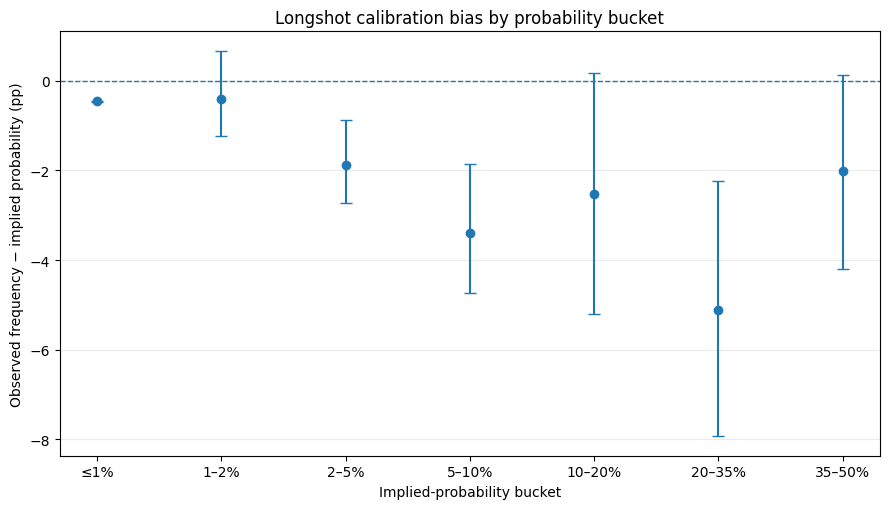

In [8]:
x = np.arange(len(bucket_summary))
y = 100 * bucket_summary['calibration_error'].to_numpy()
yerr = np.vstack([
    100 * (bucket_summary['calibration_error'] - bucket_summary['bootstrap_lo95']),
    100 * (bucket_summary['bootstrap_hi95'] - bucket_summary['calibration_error'])
])

plt.figure(figsize=(9, 5.2))
plt.axhline(0, linestyle='--', linewidth=1)
plt.errorbar(x, y, yerr=yerr, fmt='o', capsize=4)
plt.xticks(x, bucket_summary['probability_bucket'])
plt.xlabel('Implied-probability bucket')
plt.ylabel('Observed frequency − implied probability (pp)')
plt.title('Longshot calibration bias by probability bucket')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'bias_by_probability_bucket_1d.png', dpi=160)
plt.show()

The negative bias is visible across all probability buckets in this sample, but its magnitude is not constant. The largest average gap occurs in the 20–35% bucket. Bootstrap intervals quantify sampling uncertainty across markets.

## 5. Calibration by financial underlying

In [9]:
rows = []
for underlying, sub in longshots.groupby('underlying'):
    lo, hi = bootstrap_mean_ci(sub['bias'])
    rows.append({
        'underlying': underlying,
        'n_markets': len(sub),
        'avg_price': sub['price'].mean(),
        'realized_rate': sub['realized'].mean(),
        'calibration_error': sub['bias'].mean(),
        'bootstrap_lo95': lo,
        'bootstrap_hi95': hi,
    })

underlying_summary = pd.DataFrame(rows).sort_values('n_markets', ascending=False)
underlying_summary.to_csv(RESULTS_DIR / 'summary_by_underlying_1d.csv', index=False)
underlying_summary

,underlying,n_markets,avg_price,realized_rate,calibration_error,bootstrap_lo95,bootstrap_hi95
4,NVDA,857,0.2017,0.1610,-0.0407,-0.0628,-0.0179
2,GOOGL,833,0.2315,0.1825,-0.0491,-0.0728,-0.0256
1,AMZN,779,0.2238,0.1836,-0.0402,-0.0631,-0.0148
0,AAPL,773,0.2154,0.1902,-0.0252,-0.0490,-0.0011
7,TSLA,587,0.2860,0.2692,-0.0168,-0.0489,0.0163
8,WTI,583,0.2276,0.2419,0.0142,-0.0163,0.0429
6,SPY,389,0.1707,0.1671,-0.0036,-0.0339,0.0272
3,NFLX,336,0.2013,0.1845,-0.0168,-0.0503,0.0164
5,SPX,299,0.3172,0.3478,0.0307,-0.0204,0.0824
9,XAGUSD_SI,228,0.2073,0.2018,-0.0056,-0.0529,0.0423


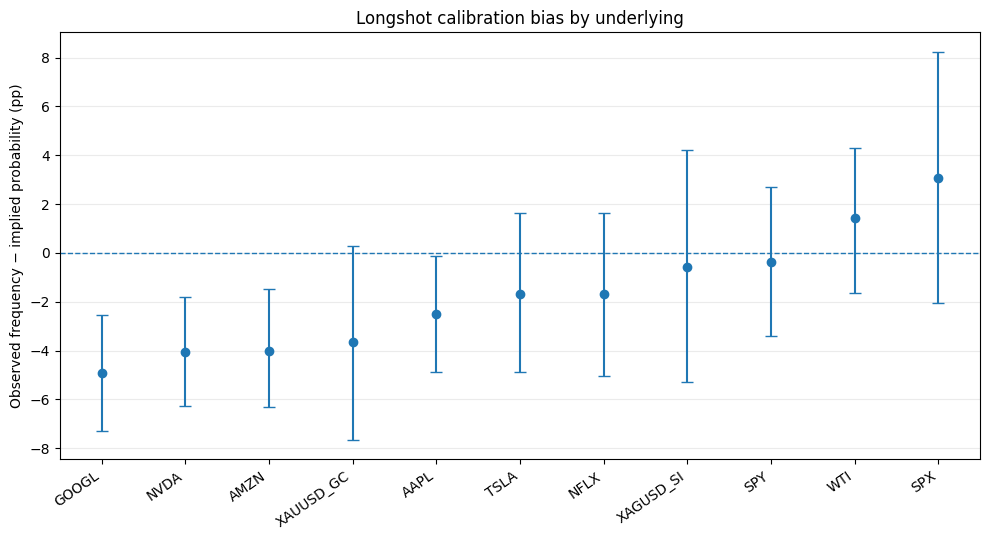

In [10]:
plot_df = underlying_summary.sort_values('calibration_error')
x = np.arange(len(plot_df))
y = 100 * plot_df['calibration_error'].to_numpy()
yerr = np.vstack([
    100 * (plot_df['calibration_error'] - plot_df['bootstrap_lo95']),
    100 * (plot_df['bootstrap_hi95'] - plot_df['calibration_error'])
])

plt.figure(figsize=(10, 5.5))
plt.axhline(0, linestyle='--', linewidth=1)
plt.errorbar(x, y, yerr=yerr, fmt='o', capsize=4)
plt.xticks(x, plot_df['underlying'], rotation=35, ha='right')
plt.ylabel('Observed frequency − implied probability (pp)')
plt.title('Longshot calibration bias by underlying')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'bias_by_underlying_1d.png', dpi=160)
plt.show()

The aggregate pattern is not universal. Some underlyings have positive estimated bias while others have negative bias. This heterogeneity is important: the result is best interpreted as a descriptive calibration pattern in the selected sample, not as a generic arbitrage claim.

## 6. Conclusion

At the 24-hour horizon, lower-probability outcomes in this sample were priced above their realized frequency on average. The gap is strongest in several intermediate longshot buckets rather than only in the most extreme probabilities.

The result is consistent with a **favorite–longshot-style calibration pattern**, but the notebook does not test trading profitability. Bid–ask spreads, fees, market impact, market-selection rules, and dependence across related contracts would all matter for an execution-based interpretation.